# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Auxiliary python functions
import time

# Local importations
from moments.bloch import compute_pauli_basis, compute_tensor_basis, compute_subset_index_map
from moments.optimization import optimize_moment_preserving_entanglement

# Hilbert apace definition

In [2]:
N = 2
d = 2 ** N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

## Analytical conditions

In general, the 3D region explored consits of a subset of $\mathbb R^3$ that satisfy certain constraints.
In particular, those are

- $x, y, z \ge 0$,
- $z \ge x + y - 1$,
- $z^2 \le 3 + x^2 + y^2 - 4xy - 4|x-y|$,
- $x = y$.

Therefore, is the intersection of a region in the first quadrant and the plane $x=y$. Since $x=y$, the inequalities become:

- $x, z \ge 0$,
- $z \ge 2x - 1$,
- $z \le \sqrt{3 - 2 x^2}$.

We can call $t$ the distance to the $z$-axis from the points in the $x=y$ plane. Thus, change the coordinates to a 2D representation where we use the intersection between the $x=y$ and $z=0$ planes as first coordinate, and $z$ as the second coordinate. Then, we would have $t = \sqrt{x^2 + y^2} = \sqrt2 x$ or $x = y = t/\sqrt2$, which transforms the inequalities as:

- $(t, z) \in [0, \sqrt2] \times [0, \sqrt3]$
- $t, z \ge 0$,
- $z \ge \sqrt2 t - 1$,
- $z^2 \le 3 - t^2$.

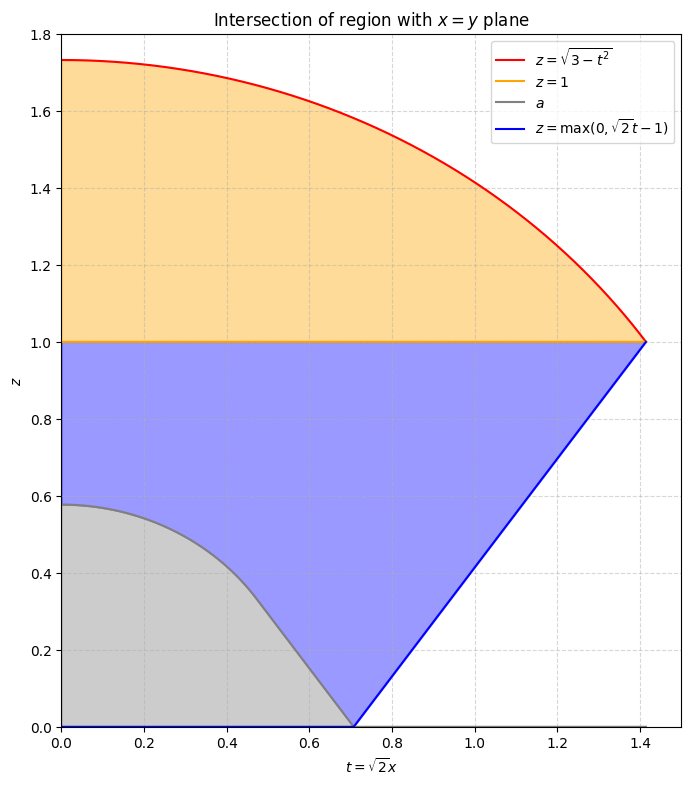

In [3]:
t = np.linspace(0, np.sqrt(2), int(np.sqrt(2) * 1000))

z_upper = np.sqrt(3 - t**2)
z_sep = np.piecewise(t, [t <= np.sqrt(2)/3, (t > np.sqrt(2)/3) & (t <= np.sqrt(2)/2)],
                     [lambda t: np.sqrt(1/3 - t**2), lambda t: 1 - np.sqrt(2) * t])
z_ent = np.ones_like(t)
z_lower = np.maximum(0, np.sqrt(2) * t - 1)

fig, ax = plt.subplots(figsize=(8, 9))

ax.fill_between(t, z_upper, z_ent, alpha=0.4, color='orange')
ax.fill_between(t, z_ent, np.where(t <= np.sqrt(2)/2, z_sep, z_lower), alpha=0.4, color='blue')
ax.fill_between(t, z_sep, z_lower, where=(t <= np.sqrt(2)/2), alpha=0.4, color='grey')

ax.plot(t, z_upper, 'red', label=r"$z = \sqrt{3 - t^2}$")
ax.plot(t, z_ent, 'orange', label=r"$z = 1$")
ax.plot(t, z_sep, 'grey', label=f"$a$")
ax.plot(t, z_lower, 'blue', label=r"$z = \max(0, \sqrt{2} t - 1)$")



ax.set(xlabel = r'$t = \sqrt{2} x$', ylabel = r'$z$', title = 'Intersection of region with $x=y$ plane',
       xlim = (0, 1.5), ylim = (0, 1.8))
ax.grid(True, alpha=0.5, linestyle="--")
ax.legend()
plt.show()

## Moment space discretization

In [4]:
D = 200
Dx, Dz = D + 1, int(np.sqrt(3) * D) + 1

x = np.linspace(0, 1, Dx)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')
Y = X

mask_state_1 = Z >= 2*X - 1
mask_state_2 = Z**2 <= 3 - 2*X**2

mask_state = mask_state_1 & mask_state_2
indices = np.where(mask_state)
total_points = len(indices[0])

points = np.column_stack((X[mask_state], X[mask_state], Z[mask_state]))
print(f"Number of points: {points.shape[0]}")

sep_vals = np.full_like(X, np.nan)
sep_vals[X <= 1/3] = np.sqrt(1/3 - 2*X[X <= 1/3]**2)
sep_vals[(X > 1/3) & (X <= 1/2)] = 1 - 2*X[(X > 1/3) & (X <= 1/2)]
sep_vals[(X > 1/2)] = 2*X[(X > 1/2)] - 1

mask_ent = (Z**2 <= 3 - 2*X**2) & (Z > 1)
mask_mix = (Z <= 1) & (Z > sep_vals)
mask_sep = (Z >= 0) & (Z <= sep_vals)

Number of points: 50725


## Optimization

In [5]:
def run_easy(d, tensor_basis, subset_index_map, Rt, optimization, max_attempts=5):
    result = None
    for _ in range(max_attempts):
        result = optimize_moment_preserving_entanglement(d, tensor_basis, subset_index_map, Rt,
                                                         metric="concurrence", optimization=optimization, cholesky_opt=True)
        if result.optimizer_info["result_success"]:
            return result
    return result

def run_hard(d, tensor_basis, subset_index_map, Rt, optimization, attempts):
    best_result = None
    best_metric = -np.inf

    for _ in range(attempts):
        result = optimize_moment_preserving_entanglement(d, tensor_basis, subset_index_map, Rt,
                                                         metric="concurrence", optimization=optimization, cholesky_opt=True)
        
        if result.metric_final > best_metric:
            best_metric = result.metric_final
            best_result = result

    return best_result

In [6]:
success, times = [], []
max_ent = np.full_like(X, np.nan, dtype=float)

for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    y_val = Y[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): float(y_val), (1, 2): float(z_val)}
    
    if mask_ent[idx, jdx]:
        optimization_result = run_easy(d, tensor_basis, subset_index_map, Rt, "maximize", max_attempts=5)

    elif mask_mix[idx, jdx]:
        optimization_result = run_hard(d, tensor_basis, subset_index_map, Rt, "maximize", attempts=10)

    elif mask_sep[idx, jdx]:
        optimization_result = run_easy(d, tensor_basis, subset_index_map, Rt, "maximize", max_attempts=5)

    else:
        continue
    
    max_ent[idx, jdx] = optimization_result.metric_final
    success.append(optimization_result.optimizer_info["result_success"])

    tf = time.time()

    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

Progress: 100.00% (50725/50725) | Time for this point: 0.125 s

Done!
Successful optimizations: 50203/50725 | Percentage: 98.97 %
Total time: 350.93 min | Average time per point: 0.415 s


In [7]:
max_attempts = 5

success, times = [], []
min_ent = np.full_like(X, np.nan, dtype=float)

for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    y_val = Y[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): float(y_val), (1, 2): float(z_val)}

    optimization_result = run_easy(d, tensor_basis, subset_index_map, Rt, "minimize", max_attempts=5)
    
    min_ent[idx, jdx] = optimization_result.metric_final
    success.append(optimization_result.optimizer_info["result_success"])

    tf = time.time()

    times.append(tf-t0)
    # Progress tracker
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

Progress: 100.00% (50725/50725) | Time for this point: 0.127 s

Done!
Successful optimizations: 50449/50725 | Percentage: 99.46 %
Total time: 54.43 min | Average time per point: 0.064 s


## Results

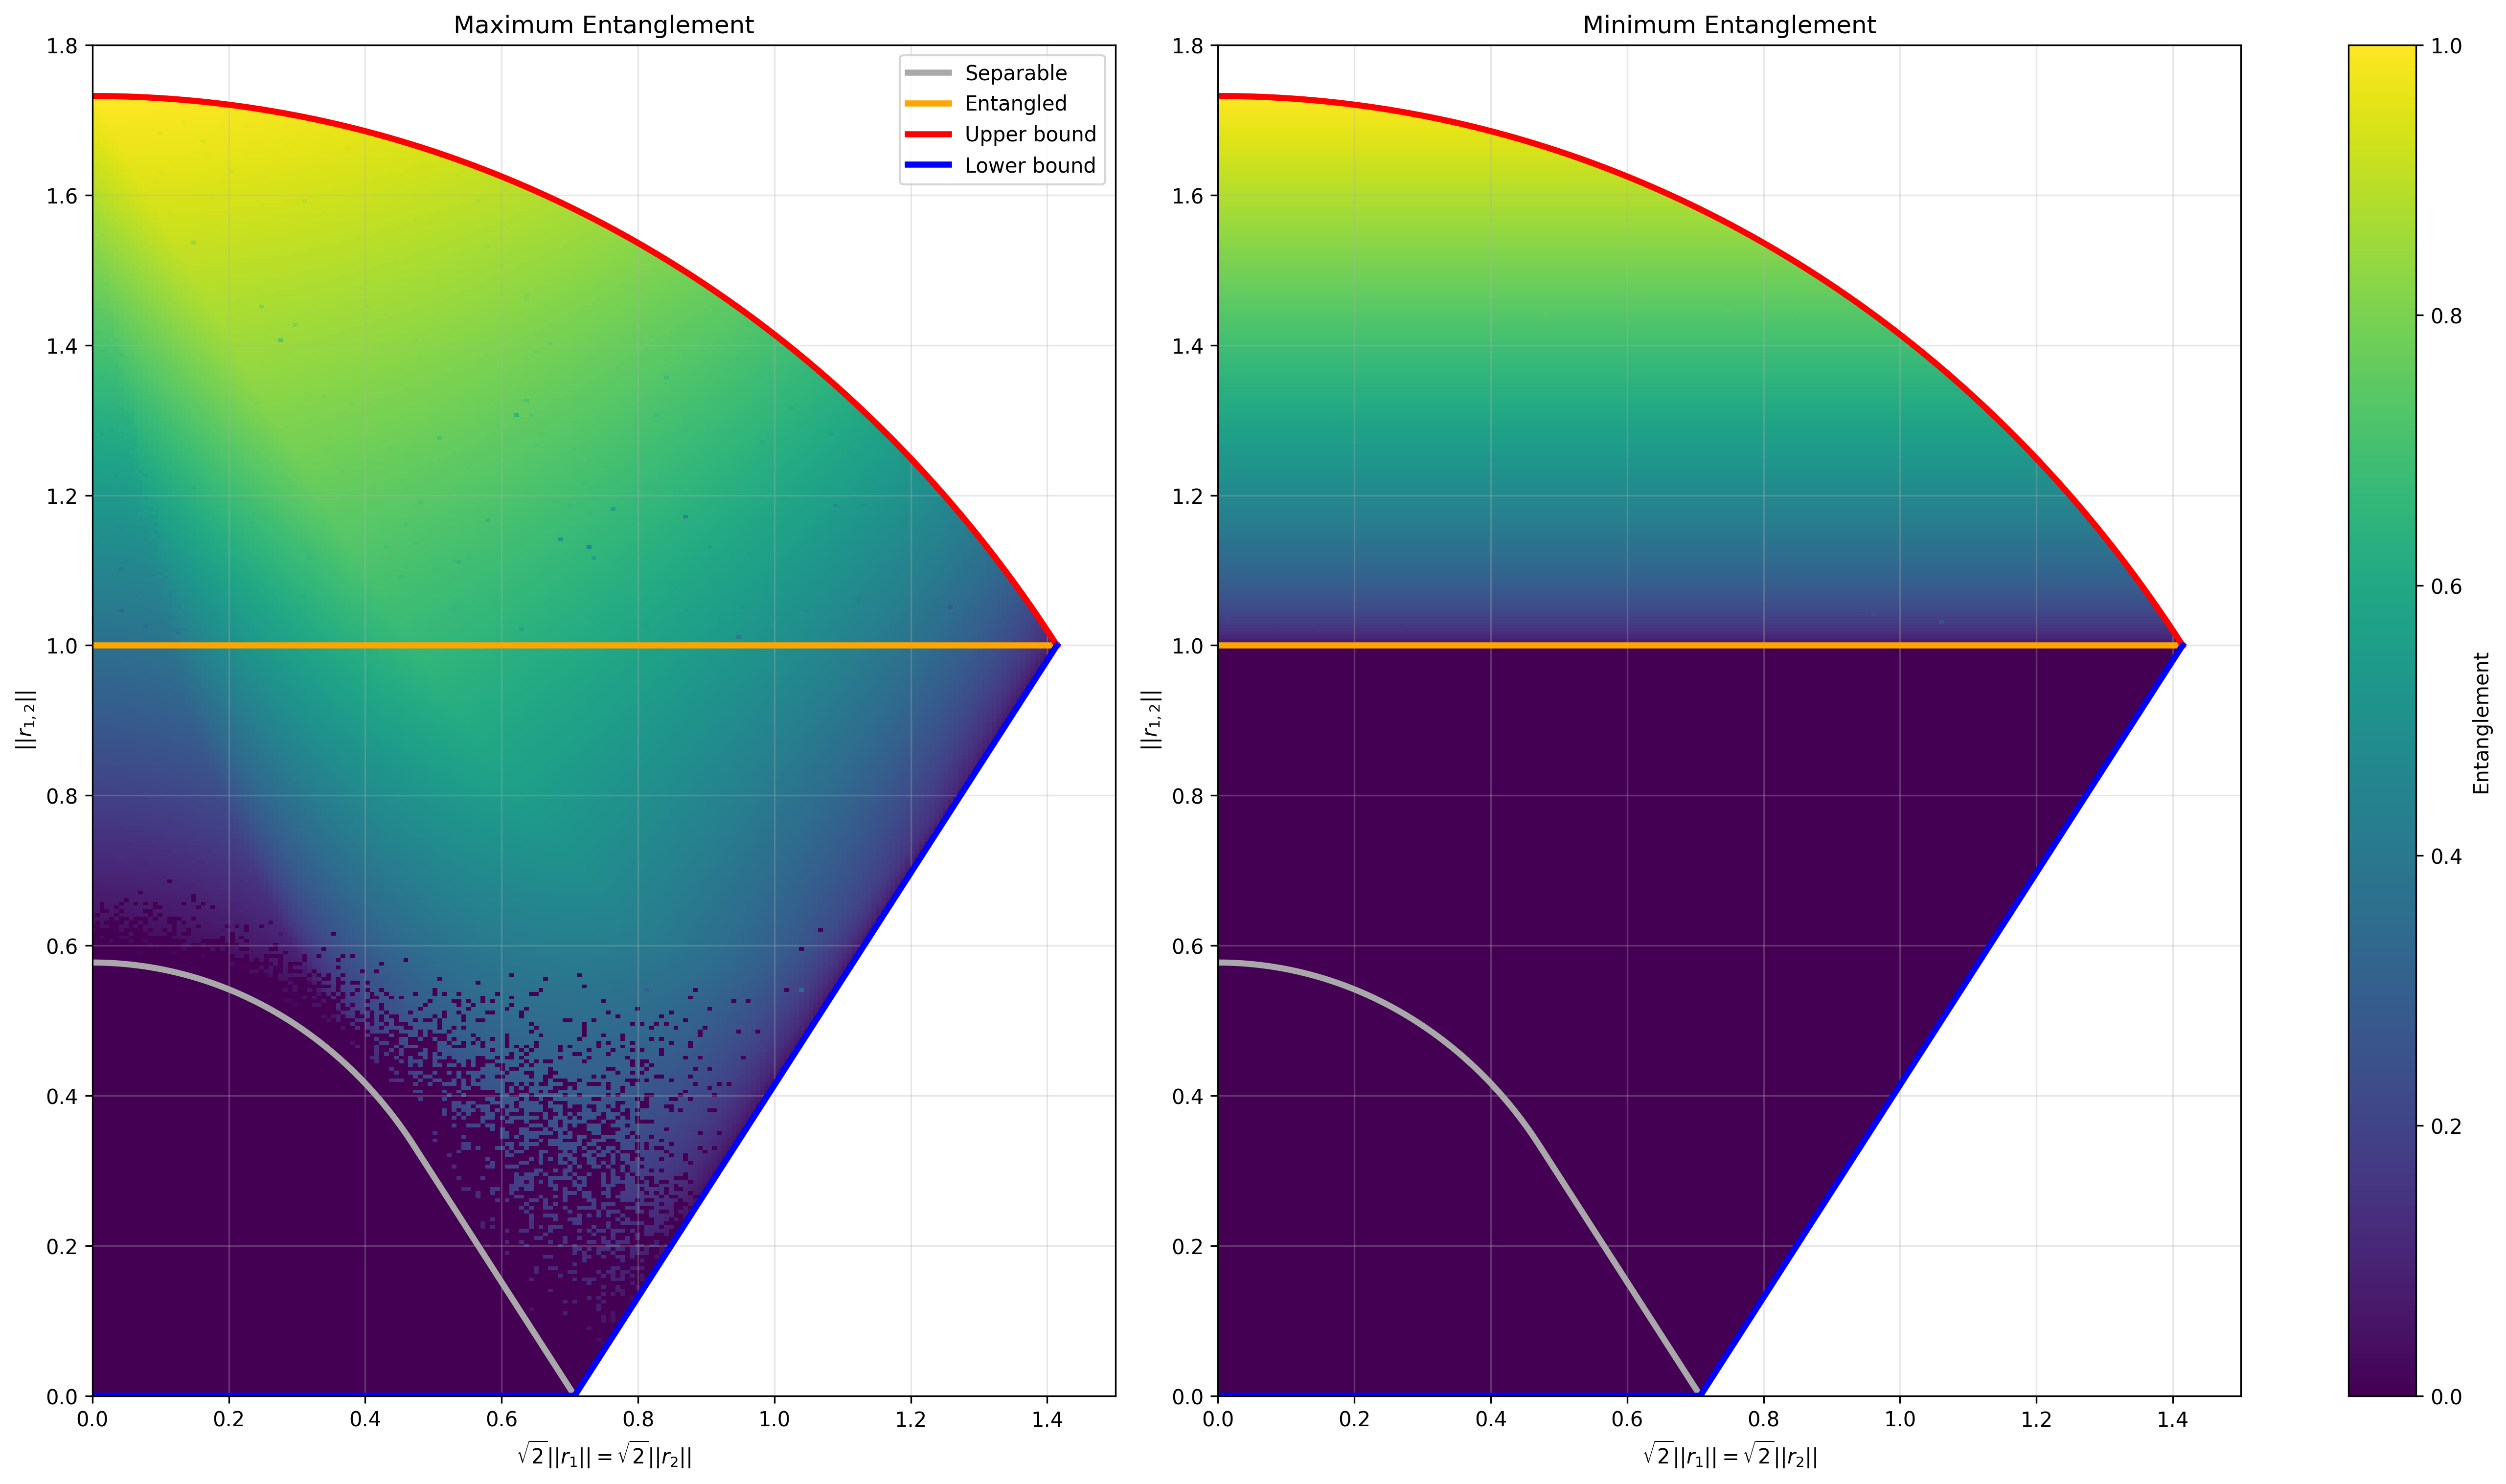

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(17, 10), constrained_layout=True, dpi=300)

mesh0 = ax[0].pcolormesh(np.sqrt(2) * X, Z, max_ent, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh1 = ax[1].pcolormesh(np.sqrt(2) * X, Z, min_ent, shading='auto', cmap='viridis', vmin=0, vmax=1)

cbar = fig.colorbar(mesh1, ax=ax.ravel().tolist(), label='Entanglement', 
                    pad=0.05, aspect=20, shrink=1)

cbar.set_ticks(list(np.linspace(0, 1, 6)))

ax[0].set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
xlim = (0, 1.5), ylim = (0, 1.8))
ax[1].set(xlabel = r"$\sqrt{2} || r_1 || = \sqrt{2} || r_2 ||$", ylabel = r"$||r_{1, 2}||$",
xlim = (0, 1.5), ylim = (0, 1.8))

ax[0].set_title('Maximum Entanglement')
ax[1].set_title('Minimum Entanglement')

t = np.linspace(0, np.sqrt(2), 1000)
z_upper = np.sqrt(3 - t**2)
z_lower = np.maximum(0, np.sqrt(2) * t - 1)
z_sep = np.piecewise(t, [t <= np.sqrt(2)/3, t > np.sqrt(2)/3],
                     [lambda t: np.sqrt(1/3 - t**2), lambda t: 1 - np.sqrt(2) * t])
z_ent = np.ones_like(t)

ax[0].plot(t, z_sep, 'darkgrey', linewidth=3, label='Separable')
ax[0].plot(t, z_ent, 'orange', linewidth=3, label='Entangled')
ax[0].plot(t, z_upper, 'r', linewidth=3, label='Upper bound')
ax[0].plot(t, z_lower, 'b', linewidth=3, label='Lower bound')

ax[1].plot(t, z_sep, 'darkgrey', linewidth=3, label='Separable')
ax[1].plot(t, z_ent, 'orange', linewidth=3, label='Entangled')
ax[1].plot(t, z_upper, 'r', linewidth=3, label='Upper bound')
ax[1].plot(t, z_lower, 'b', linewidth=3, label='Lower bound')

ax[0].legend(loc='upper right')
ax[0].grid(True, alpha=0.3)
ax[1].grid(True, alpha=0.3)

plt.show()

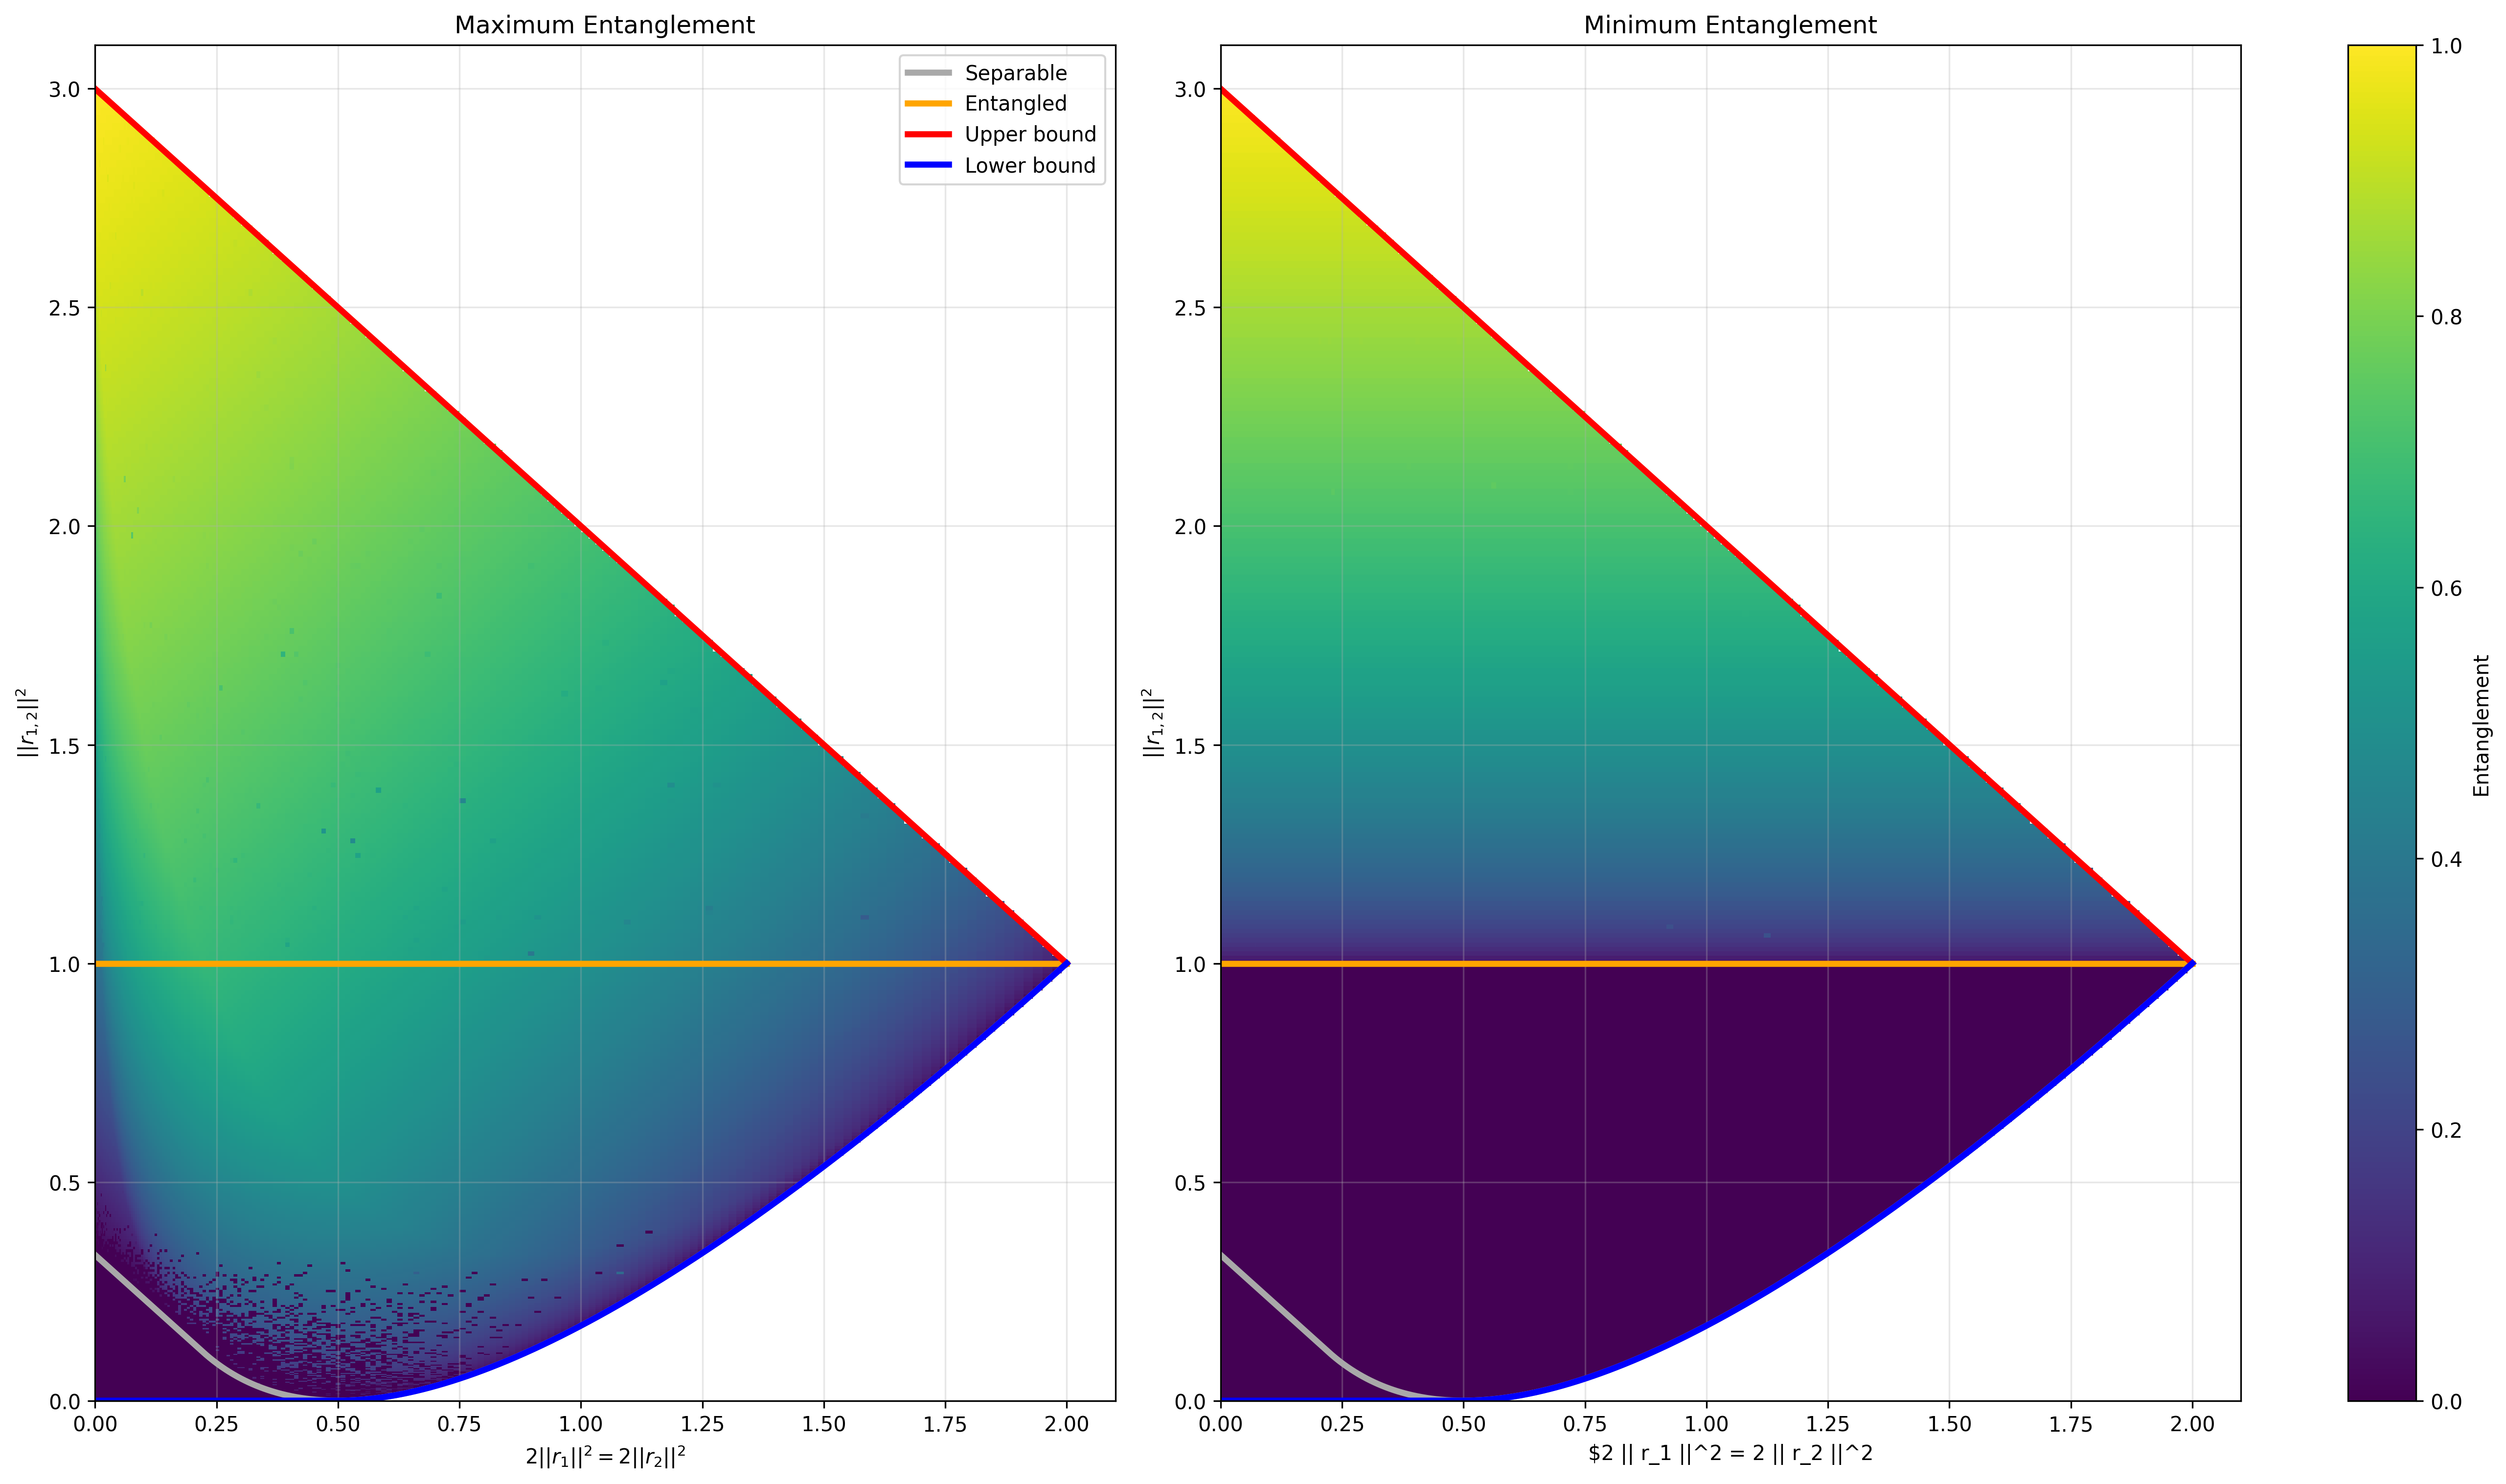

In [9]:
R1 = X**2
R12 = Z**2

fig, ax = plt.subplots(1, 2, figsize=(17, 10), constrained_layout=True, dpi=300)

mesh0 = ax[0].pcolormesh(2 * R1, R12, max_ent, shading='auto', cmap='viridis', vmin=0, vmax=1)
mesh1 = ax[1].pcolormesh(2 * R1, R12, min_ent, shading='auto', cmap='viridis', vmin=0, vmax=1)

cbar = fig.colorbar(mesh1, ax=ax.ravel().tolist(), label='Entanglement', 
                    pad=0.05, aspect=20, shrink=1)

cbar.set_ticks(list(np.linspace(0, 1, 6)))

ax[0].set(xlabel = r"$2 || r_1 ||^2 = 2 || r_2 ||^2$", ylabel = r"$||r_{1, 2}||^2$",
          xlim = (0, 2.1), ylim = (0, 3.1))
ax[1].set(xlabel = r"$2 || r_1 ||^2 = 2 || r_2 ||^2", ylabel = r"$||r_{1, 2}||^2$",
          xlim = (0, 2.1), ylim = (0, 3.1))

ax[0].set_title('Maximum Entanglement')
ax[1].set_title('Minimum Entanglement')

t2 = np.linspace(0, 2, 1000)
R12_upper = 3 - t2
R12_lower = np.where(t2 <= 0.5, 0, (np.sqrt(2 * t2) - 1)**2)
R12_sep = np.where(t2 <= 2/9, 1/3 - t2, (1 - np.sqrt(2 * t2))**2)
R12_ent = np.ones_like(t2)

ax[0].plot(t2, R12_sep, 'darkgrey', linewidth=3, label='Separable')
ax[0].plot(t2, R12_ent, 'orange', linewidth=3, label='Entangled')
ax[0].plot(t2, R12_upper, 'r', linewidth=3, label='Upper bound')
ax[0].plot(t2, R12_lower, 'b', linewidth=3, label='Lower bound')

ax[1].plot(t2, R12_sep, 'darkgrey', linewidth=3, label='Separable')
ax[1].plot(t2, R12_ent, 'orange', linewidth=3, label='Entangled')
ax[1].plot(t2, R12_upper, 'r', linewidth=3, label='Upper bound')
ax[1].plot(t2, R12_lower, 'b', linewidth=3, label='Lower bound')

ax[0].legend(loc='upper right')
ax[0].grid(True, alpha=0.3)
ax[1].grid(True, alpha=0.3)

plt.show()

## Save data

In [11]:
np.save("max_concurrence_2q_sym_plane", max_ent)
np.save("min_concurrence_2q_sym_plane", min_ent)